In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.feature_selection import SelectKBest, chi2, RFE, SelectFromModel

In [2]:
df = pd.read_csv('bike.csv')

In [3]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1/1/2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,16
1,2,1/1/2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,40
2,3,1/1/2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,32
3,4,1/1/2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,13
4,5,1/1/2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,12/31/2012,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,119
17375,17376,12/31/2012,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,89
17376,17377,12/31/2012,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,90
17377,17378,12/31/2012,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,61


In [4]:
df['is_high_demand'] = np.where(df['cnt'] >= 50, 1, 0)
df['is_high_demand'] = df['is_high_demand'].astype('category')

Y = df['is_high_demand']
X = df.drop('is_high_demand', axis=1)

X = X.drop('cnt', axis=1)
X = X.drop('yr', axis=1)
X = X.drop('hr', axis=1)
X = X.drop('workingday', axis=1)
X = X.drop('weathersit', axis=1)
X = X.drop('instant', axis=1)
X = X.drop('dteday', axis=1)

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   season     17379 non-null  int64  
 1   mnth       17379 non-null  int64  
 2   holiday    17379 non-null  int64  
 3   weekday    17379 non-null  int64  
 4   temp       17379 non-null  float64
 5   atemp      17379 non-null  float64
 6   hum        17379 non-null  float64
 7   windspeed  17379 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 1.1 MB


In [6]:
X_processed = X.copy()

category_columns: list[str] = X_processed.select_dtypes(include=['category']).columns # собираем колонки помеченные как category

# Применяем One-Hot Encoding
X_processed = pd.get_dummies(X_processed, columns=category_columns,drop_first=True) # drop_first=True позволяет избежать мультиколлинеарности, удаляя первый уровень категориальной переменной.


In [7]:
X_processed

,season,mnth,holiday,weekday,temp,atemp,hum,windspeed
0,1,1,0,6,0.24,0.2879,0.81,0.0000
1,1,1,0,6,0.22,0.2727,0.80,0.0000
2,1,1,0,6,0.22,0.2727,0.80,0.0000
3,1,1,0,6,0.24,0.2879,0.75,0.0000
4,1,1,0,6,0.24,0.2879,0.75,0.0000
...,...,...,...,...,...,...,...,...
17374,1,12,0,1,0.26,0.2576,0.60,0.1642
17375,1,12,0,1,0.26,0.2576,0.60,0.1642
17376,1,12,0,1,0.26,0.2576,0.60,0.1642
17377,1,12,0,1,0.26,0.2727,0.56,0.1343


In [8]:
# Выбираем числовые признаки
numeric_features = X_processed.select_dtypes(include=['float64']).columns.tolist()

# Инициализируем scaler
scaler = MinMaxScaler()

# Применяем нормализацию
X_processed[numeric_features] = scaler.fit_transform(X_processed[numeric_features])

In [9]:
X_processed

,season,mnth,holiday,weekday,temp,atemp,hum,windspeed
0,1,1,0,6,0.224490,0.2879,0.81,0.000000
1,1,1,0,6,0.204082,0.2727,0.80,0.000000
2,1,1,0,6,0.204082,0.2727,0.80,0.000000
3,1,1,0,6,0.224490,0.2879,0.75,0.000000
4,1,1,0,6,0.224490,0.2879,0.75,0.000000
...,...,...,...,...,...,...,...,...
17374,1,12,0,1,0.244898,0.2576,0.60,0.193018
17375,1,12,0,1,0.244898,0.2576,0.60,0.193018
17376,1,12,0,1,0.244898,0.2576,0.60,0.193018
17377,1,12,0,1,0.244898,0.2727,0.56,0.157870


In [10]:
from sklearn.model_selection import cross_val_score

def train_and_evaluate(X, Y):
    # Разделение данных на обучающую и тестовую выборки
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42, stratify=Y)

    # Инициализация модели
    model = LogisticRegression(max_iter=1000)

    # Обучение модели
    model.fit(X_train, Y_train)

    # Предсказания на обучающей выборке
    Y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(Y_train, Y_train_pred)

    # Предсказания на тестовой выборке
    Y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(Y_test, Y_test_pred)

    # Вывод результатов
    print(f"Точность на обучающей выборке: {train_accuracy:.4f}")
    print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

    # Классификационный отчет
    print("\nКлассификационный отчет на тестовой выборке:")
    print(classification_report(Y_test, Y_test_pred))

    return model

In [11]:
train_and_evaluate(X_processed, Y)

Точность на обучающей выборке: 0.7424
Точность на тестовой выборке: 0.7353

Классификационный отчет на тестовой выборке:
              precision    recall  f1-score   support

           0       0.54      0.28      0.37       964
           1       0.77      0.91      0.83      2512

    accuracy                           0.74      3476
   macro avg       0.66      0.59      0.60      3476
weighted avg       0.71      0.74      0.70      3476



LogisticRegression(max_iter=1000)

In [12]:
# Функция для удаления выбросов на основе межквартильного размаха (1.5 IQR)
def remove_outliers_based_on_iqr(X, y, iqr_multiplier=1.5):
    # Убедимся, что работаем только с числовыми данными
    X_numeric = X.select_dtypes(include=['number'])

    # Рассчитываем первый и третий квартили для каждой числовой переменной
    Q1 = X_numeric.quantile(0.25)
    Q3 = X_numeric.quantile(0.75)

    # Вычисляем межквартильный размах (IQR)
    IQR = Q3 - Q1

    # Оставляем только те значения, которые находятся в диапазоне [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    X_filtered = X_numeric[~((X_numeric < (Q1 - iqr_multiplier * IQR)) | (X_numeric > (Q3 + iqr_multiplier * IQR))).any(axis=1)]

    # Синхронизируем y с отфильтрованными X
    y_filtered = y.loc[X_filtered.index]

    return X_filtered, y_filtered

In [13]:
X_iqr, y_iqr = remove_outliers_based_on_iqr(X_processed, Y, iqr_multiplier=3)

In [14]:
X_processed.describe()

,season,mnth,holiday,weekday,temp,atemp,hum,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,6.537775,0.028770,3.003683,0.486722,0.475775,0.627229,0.223460
std,1.106918,3.438776,0.167165,2.005771,0.196486,0.171850,0.192930,0.143811
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,0.000000,1.000000,0.326531,0.333300,0.480000,0.122840
50%,3.000000,7.000000,0.000000,3.000000,0.489796,0.484800,0.630000,0.228047
75%,3.000000,10.000000,0.000000,5.000000,0.653061,0.621200,0.780000,0.298225
max,4.000000,12.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
train_and_evaluate(X_iqr, y_iqr)

Точность на обучающей выборке: 0.7417
Точность на тестовой выборке: 0.7368

Классификационный отчет на тестовой выборке:
              precision    recall  f1-score   support

           0       0.54      0.29      0.38       928
           1       0.77      0.91      0.83      2446

    accuracy                           0.74      3374
   macro avg       0.66      0.60      0.60      3374
weighted avg       0.71      0.74      0.71      3374



LogisticRegression(max_iter=1000)

In [16]:

# Функция для удаления выбросов на основе среднего значения

def remove_outliers_based_on_mean(X, y, mean_multiplier=2):
    # Убедимся, что работаем только с числовыми данными
    X_numeric = X.select_dtypes(include=['number'])

    # Рассчитываем среднее значение и стандартное отклонение для каждой переменной
    mean_values = X_numeric.mean()
    std_values = X_numeric.std()

    # Устанавливаем верхний и нижний пороги на основе среднего значения и множителя стандартного отклонения
    lower_threshold = mean_values - mean_multiplier * std_values
    upper_threshold = mean_values + mean_multiplier * std_values

    # Фильтруем наблюдения, которые находятся в пределах этих порогов по всем признакам
    X_filtered = X_numeric[~((X_numeric < lower_threshold) | (X_numeric > upper_threshold)).any(axis=1)]

    # Синхронизируем y с отфильтрованными X
    y_filtered = y.loc[X_filtered.index]

    return X_filtered, y_filtered

In [17]:
X_mean, y_mean = remove_outliers_based_on_mean(X_processed.copy(), Y.copy())

In [18]:
train_and_evaluate(X_mean, y_mean)

Точность на обучающей выборке: 0.7345
Точность на тестовой выборке: 0.7364

Классификационный отчет на тестовой выборке:
              precision    recall  f1-score   support

           0       0.56      0.27      0.36       873
           1       0.76      0.92      0.83      2257

    accuracy                           0.74      3130
   macro avg       0.66      0.59      0.60      3130
weighted avg       0.71      0.74      0.70      3130



LogisticRegression(max_iter=1000)

In [19]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_new = selector.fit_transform(X_scaled, Y)

selected_features = X.columns[selector.get_support()]

X_train, X_test, Y_train, Y_test = train_test_split(X_new, Y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

model = LogisticRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:779: UserWarning: k=10 is greater than n_features=8. All the features will be returned.
  warnings.warn(


In [21]:
print("Точность на тестовой выборке:", accuracy_score(Y_test, Y_pred))
print("Классификационный отчет:\n", classification_report(Y_test, Y_pred))

Точность на тестовой выборке: 0.7407940161104718
Классификационный отчет:
               precision    recall  f1-score   support

           0       0.55      0.28      0.37       948
           1       0.77      0.91      0.84      2528

    accuracy                           0.74      3476
   macro avg       0.66      0.60      0.60      3476
weighted avg       0.71      0.74      0.71      3476



Коэффициенты модели без регуляризации: [[ 1.58298639e-01 -2.73636694e-03 -3.95650940e-01  9.57147966e-03
   9.69023376e-01  2.74568041e+00 -3.98617528e+00  1.09807523e+00]]
Коэффициенты модели с регуляризацией: [[ 1.57029491e-01 -2.28360716e-03 -3.84897691e-01  9.93205925e-03
   5.95174062e-01  3.19792438e+00 -4.01633274e+00  1.12007999e+00]]
Отобранные признаки: Index(['season', 'mnth', 'holiday', 'weekday', 'temp', 'atemp', 'hum',
       'windspeed'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Коэффициенты модели после отбора признаков: [[ 1.57226450e-01 -2.34106371e-03 -3.82520626e-01  1.03201259e-02
   1.13103297e-01  3.74798941e+00 -4.01230809e+00  1.15699530e+00]]


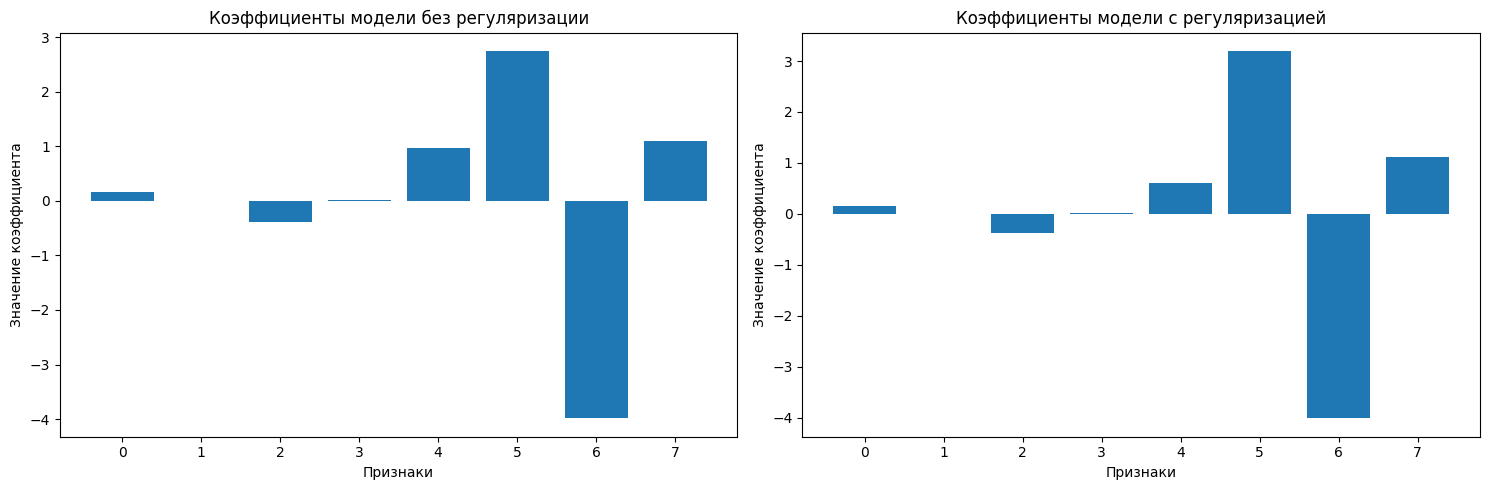

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
import numpy as np
import matplotlib.pyplot as plt

# Обучаем модель без регуляризации
model_no_penalty = LogisticRegression(solver='lbfgs', max_iter=1000)
model_no_penalty.fit(X_processed, Y)

# Выводим коэффициенты модели без регуляризации
coefficients_no_penalty = model_no_penalty.coef_
print("Коэффициенты модели без регуляризации:", coefficients_no_penalty)

# Инициализируем модель с L1-регуляризацией
model_with_penalty = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

# Обучаем модель с регуляризацией
model_with_penalty.fit(X_processed, Y)

# Выводим коэффициенты модели с регуляризацией
coefficients_with_penalty = model_with_penalty.coef_
print("Коэффициенты модели с регуляризацией:", coefficients_with_penalty)

# Используем SelectFromModel для отбора признаков
selector = SelectFromModel(model_with_penalty, prefit=True)
X_embedded = selector.transform(X_processed)

# Получаем список отобранных признаков
selected_features = X_processed.columns[selector.get_support()]
print("Отобранные признаки:", selected_features)

# Обучаем модель на отобранных признаках
model_embedded = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_embedded.fit(X_embedded, Y)

# Выводим коэффициенты модели после отбора признаков
coefficients_embedded = model_embedded.coef_
print("Коэффициенты модели после отбора признаков:", coefficients_embedded)

# Визуализация коэффициентов моделей
plt.figure(figsize=(15, 5))

# Коэффициенты модели без регуляризации
plt.subplot(1, 2, 1)
plt.bar(range(len(coefficients_no_penalty[0])), coefficients_no_penalty[0])
plt.title("Коэффициенты модели без регуляризации")
plt.xlabel("Признаки")
plt.ylabel("Значение коэффициента")

# Коэффициенты модели с регуляризацией
plt.subplot(1, 2, 2)
plt.bar(range(len(coefficients_with_penalty[0])), coefficients_with_penalty[0])
plt.title("Коэффициенты модели с регуляризацией")
plt.xlabel("Признаки")
plt.ylabel("Значение коэффициента")

plt.tight_layout()
plt.show()

In [23]:
# Преобразуем X_embedded в DataFrame
X_embedded_df = pd.DataFrame(X_embedded, columns=selected_features)

# Обучаем и оцениваем модель
model = train_and_evaluate(X_embedded_df, Y)

Точность на обучающей выборке: 0.7424
Точность на тестовой выборке: 0.7353

Классификационный отчет на тестовой выборке:
              precision    recall  f1-score   support

           0       0.54      0.28      0.37       964
           1       0.77      0.91      0.83      2512

    accuracy                           0.74      3476
   macro avg       0.66      0.59      0.60      3476
weighted avg       0.71      0.74      0.70      3476



In [25]:

import numpy as np

# Сигмоидная функция
def sigmoid(z):
    # Убедимся, что z это numpy массив
    return 1 / (1 + np.exp(-z))

# Простая реализация логистической регрессии
class OwnLogisticRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations

    # Метод для обучения модели
    def fit(self, X, y):
        # Инициализация весов
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        # Градиентный спуск
        for idx_,_ in enumerate(range(self.iterations)):
            # Линейная комбинация
            linear_model = np.dot(X, self.weights) + self.bias
            # Применяем сигмоиду для предсказания
            y_pred = sigmoid(linear_model)

            # Вычисляем градиенты
            dw = (1 / len(X)) * np.dot(X.T, (y_pred - y))
            db = (1 / len(X)) * np.sum(y_pred - y)

            # Обновляем веса и смещение
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    # Метод для предсказания
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        print("regression",linear_model)
        y_pred = sigmoid(linear_model)
        print("sigmoid",y_pred)
        # Возвращаем метки классов (0 или 1)
        return [1 if i > 0.5 else 0 for i in y_pred]

In [26]:
X = np.array([[0.1, 1.2], [1.1, 2.2], [2.1, 1.9], [1.0, 1.0]])
y = np.array([0, 1, 1, 0])

model = OwnLogisticRegression(learning_rate=0.1, iterations=1000)
model.fit(X, y)
predictions = model.predict(X)


regression [-2.48902698  1.89302513  3.0459193  -1.27754449]
sigmoid [0.07663102 0.86910007 0.95460602 0.2179685 ]


In [27]:
import numpy as np
from sklearn.model_selection import KFold, ShuffleSplit, train_test_split, cross_val_score

In [28]:
# K-Fold Cross-Validation
def k_fold_cross_validation(X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []

    # Реализация K-Fold вручную
    for train_index, test_index in kf.split(X):
        model = LogisticRegression(max_iter=1000)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Обучение модели на тренировочной выборке
        model.fit(X_train, y_train)

        # Предсказания на тестовой выборке
        y_pred = model.predict(X_test)

        # Оценка точности
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)

    # Выводим среднюю точность и точности по каждому фолду
    print(f"K-Fold Cross-Validation - Средняя точность: {np.mean(accuracies)}")
    print(f"Точности по каждому фолду: {accuracies}")

# Пример использования:
k_fold_cross_validation(X = X_processed.to_numpy(), y = Y.to_numpy())

K-Fold Cross-Validation - Средняя точность: 0.7404341879775811
Точности по каждому фолду: [0.7410817031070196, 0.7399309551208285, 0.7364787111622555, 0.7384925201380897, 0.7461870503597122]


In [29]:
# ShuffleSplit Cross-Validation
def shuffle_split_cross_validation(X, y, n_splits=5, test_size=0.4):
    ss = ShuffleSplit(n_splits=n_splits, test_size=test_size)
    accuracies = []

    # Реализация ShuffleSplit вручную
    for train_index, test_index in ss.split(X):
        model = LogisticRegression(max_iter=1000)
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Обучение модели на тренировочной выборке
        model.fit(X_train, y_train)

        # Предсказания на тестовой выборке
        y_pred = model.predict(X_test)

        # Оценка точности
        accuracy = accuracy_score(y_test, y_pred)
        accuracies.append(accuracy)

    # Выводим среднюю точность и точности по каждому разделению
    print(f"ShuffleSplit Cross-Validation - Средняя точность: {np.mean(accuracies)}")
    print(f"Точности по каждому разделению: {accuracies}")

# Пример использования:
shuffle_split_cross_validation(X_processed.to_numpy(), Y.to_numpy())


ShuffleSplit Cross-Validation - Средняя точность: 0.7369965477560415
Точности по каждому разделению: [0.7406501726121979, 0.7351841196777905, 0.7300057537399309, 0.7383486766398158, 0.7407940161104718]


In [30]:
# Train-Test-Validation Split
def train_test_validation_split(X, y):
    model = LogisticRegression(max_iter=1000)
    # Разделяем данные на тренировочные и оставшиеся (валидация + тест)
    X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.2, random_state=42)

    # Разделяем оставшиеся данные на валидационные и тестовые
    X_train_train, X_test, y_train_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    # Обучаем модель на тренировочных данных
    model.fit(X_train_train, y_train_train)

    # Оцениваем на валидационных данных
    y_valid_pred = model.predict(X_validation)
    validation_accuracy = accuracy_score(y_validation, y_valid_pred)
    print(f"Точность на валидационных данных: {validation_accuracy}")

    # Оцениваем на тестовых данных
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Точность на тестовых данных: {test_accuracy}")

# Пример использования:
train_test_validation_split(X_processed.to_numpy(), Y.to_numpy())

Точность на валидационных данных: 0.7379171461449943
Точность на тестовых данных: 0.7479323984178353
